In [1]:
import pandas as pd
import numpy as np
import requests
import json
from bs4 import BeautifulSoup
import re
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
import itertools
import warnings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split

In [2]:
# Parsing the website and getting the data
urls = [
        'https://charts.finance.ua/ua/currency/data-archive?for=interbank&source=1&indicator=eur',
       'https://charts.finance.ua/ua/currency/data-archive?for=interbank&source=1&indicator=usd',
       'https://charts.finance.ua/ru/currency/data-archive?for=cash&source=0&indicator=pln'
]

df = pd.DataFrame(columns=['Date', 'Buy', 'Sell'])
# df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', dayfirst=True)
response = requests.get(urls[0])
js = json.JSONDecoder().decode(response.text)
df = pd.DataFrame(js, columns=['Date', 'Buy', 'Sell']).set_index('Date')
# df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', dayfirst=True)

response = requests.get(urls[1])
js = json.JSONDecoder().decode(response.text)
# df = pd.concat([df, pd.DataFrame(js)], axis=1, join='outer')
df = df.join(pd.DataFrame(js, columns=['Date', 'Buy', 'Sell']).set_index('Date'), on='Date', how='right', lsuffix='_EUR', rsuffix='_USD')

response = requests.get(urls[2])
js = json.JSONDecoder().decode(response.text)
# df = pd.concat([df, pd.DataFrame(js)], axis=1, join='outer')
df = df.join(pd.DataFrame(js, columns=['Date', 'Buy', 'Sell']).set_index('Date'), on='Date', how='right', rsuffix='_PLN')

df.columns = ['Date', 'Buy_EUR', 'Sell_EUR', 'Buy_USD', 'Sell_USD', 'Buy_PLN', 'Sell_PLN']
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', dayfirst=True)
df = df.set_index('Date').dropna()
df = df.astype(float)

# Turning list to DataFrame for more comfortable usage later and cutting to 2024
df_full = df[(df.index < '2024-12-31')].copy()
# for col in df_full.columns:
#     if col != 'Date':
#         df_full[col] = df_full[col].astype(float)

# df_full = df_full.set_index('Date').dropna()

df_1 = df_full[(df_full.index > '2022-08-01') & (df_full.index < '2024-02-15')]
df = df_full[(df_full.index > '2022-08-01') & (df_full.index< '2023-10-31')]

df_full

,Buy_EUR,Sell_EUR,Buy_USD,Sell_USD,Buy_PLN,Sell_PLN
Date,,,,,,
2020-11-27,34.0526,34.0824,28.515,28.540,7.3595,7.5754
2020-11-30,34.1769,34.1948,28.495,28.510,7.3821,7.5550
2020-12-01,34.1948,34.2160,28.510,28.530,7.3954,7.5850
2020-12-02,34.1892,34.2105,28.300,28.320,7.4187,7.6523
2020-12-03,34.3524,34.3828,28.255,28.280,7.4262,7.6308
...,...,...,...,...,...,...
2024-12-24,43.6261,43.6301,41.920,41.940,10.0375,10.4525
2024-12-25,43.5848,43.6140,41.800,41.840,9.9000,10.4250
2024-12-26,43.5449,43.5552,41.850,41.880,9.9500,10.4250


In [7]:
# Saving the results of parsing to a file(.csv format)
file_path = Path('data/Eur_Uah.csv')
file_path.parent.mkdir(parents=True, exist_ok=True)

if file_path.is_file():
    print(f'Файл "{file_path}" вже існує.')
else:
    df.to_csv(file_path, index=False)
    print(f'Файл успішно збережено до "{file_path}"')

Файл успішно збережено до "data/Eur_Uah.csv"


In [37]:
def draw_plots(dtf, second_arg):
   fig, ax = plt.subplots(1, 2, figsize=(15, 3))
   # fig.tight_layout()

   # Common plot with basic information and EMA trend
   ax[0].tick_params(axis='x', labelrotation=45)
   ax[0].set_xlabel(f'Графік реальних даних з накладеною EMA для {second_arg}')
   ax[0].plot(dtf[second_arg], color='g')
   ax[0].plot(dtf[second_arg].ewm(span=50, adjust=False).mean(), color='b')

   # Histogram
   ax[1].hist(dtf[second_arg], bins=np.arange(round(dtf[second_arg].min()), round(dtf[second_arg].max() + 1), 0.5), edgecolor='black')
   ax[1].set_xlabel('Графік емпіричного розподілу частот')

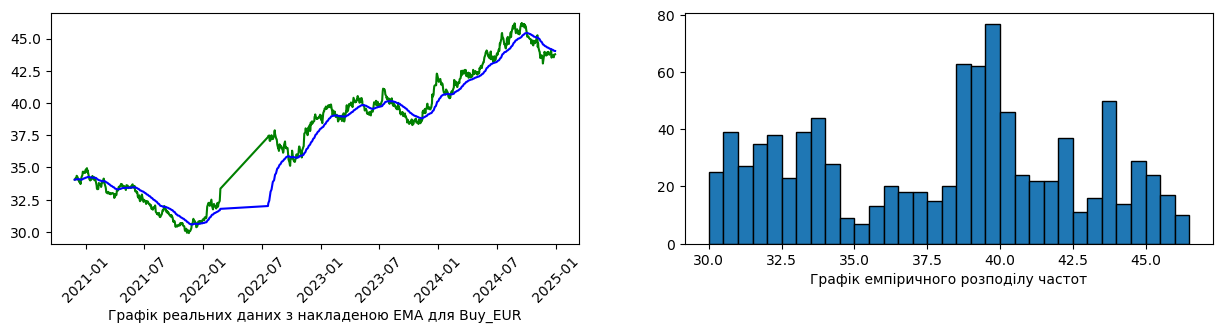

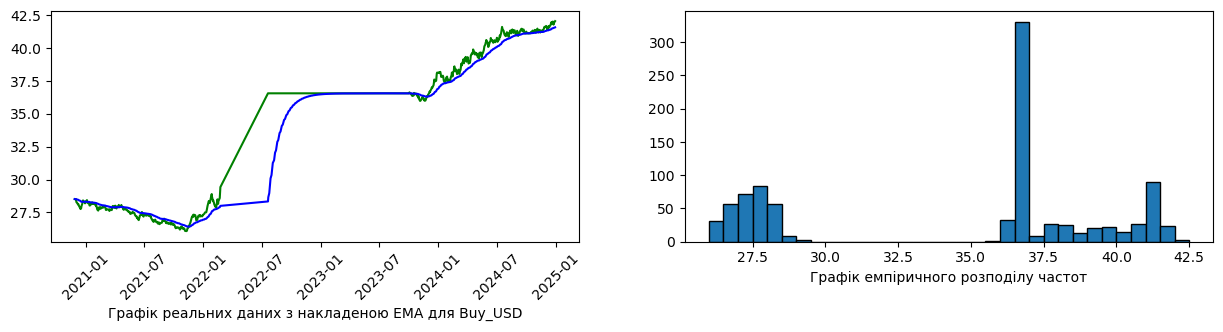

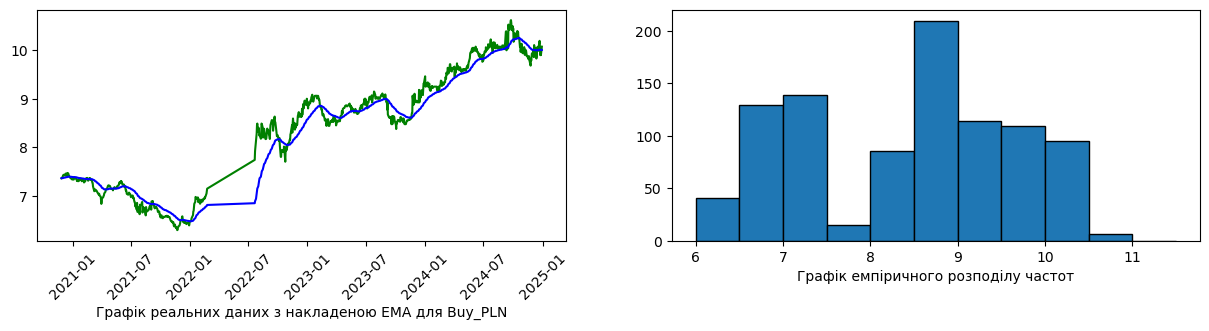

In [38]:
draw_plots(df_full, 'Buy_EUR')
draw_plots(df_full, 'Buy_USD')
draw_plots(df_full, 'Buy_PLN')

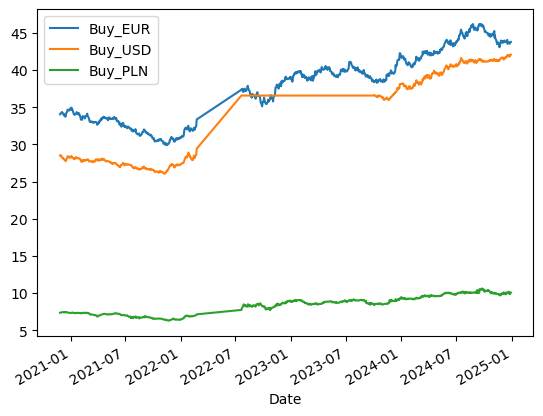

In [3]:
df_full[['Buy_EUR', 'Buy_USD', 'Buy_PLN']].plot();

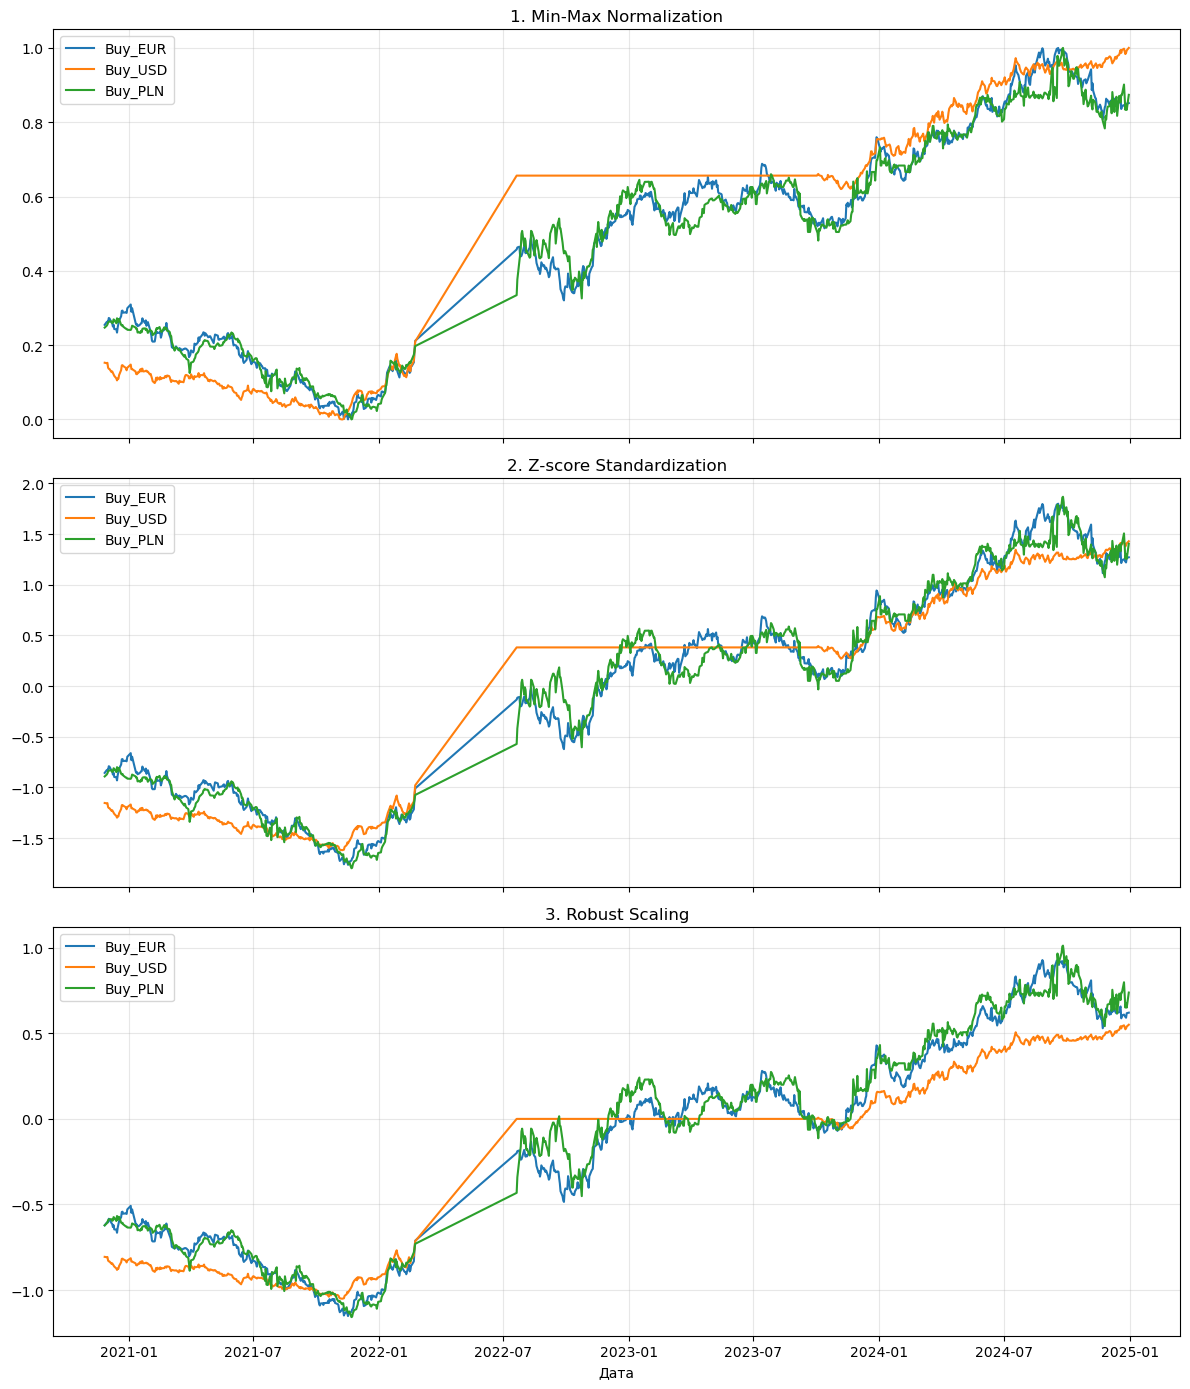

In [6]:
target_cols = ['Buy_EUR', 'Buy_USD', 'Buy_PLN']
df_to_analyse = df_full[target_cols].copy()

scaler_minmax = MinMaxScaler()
scaler_std = StandardScaler()
scaler_rob = RobustScaler()

df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df_to_analyse), columns=target_cols, index=df_full.index)
df_std = pd.DataFrame(scaler_std.fit_transform(df_to_analyse), columns=target_cols, index=df_full.index)
df_robust = pd.DataFrame(scaler_rob.fit_transform(df_to_analyse), columns=target_cols, index=df_full.index)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 14), sharex=True)

for col in target_cols:
    axes[0].plot(df_minmax.index, df_minmax[col], label=col)
    axes[1].plot(df_std.index, df_std[col], label=col)
    axes[2].plot(df_robust.index, df_robust[col], label=col)

axes[0].set_title('1. Min-Max Normalization')
axes[0].legend()
# axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].set_title('2. Z-score Standardization')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_title('3. Robust Scaling')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xlabel('Дата')

plt.tight_layout()
plt.show()

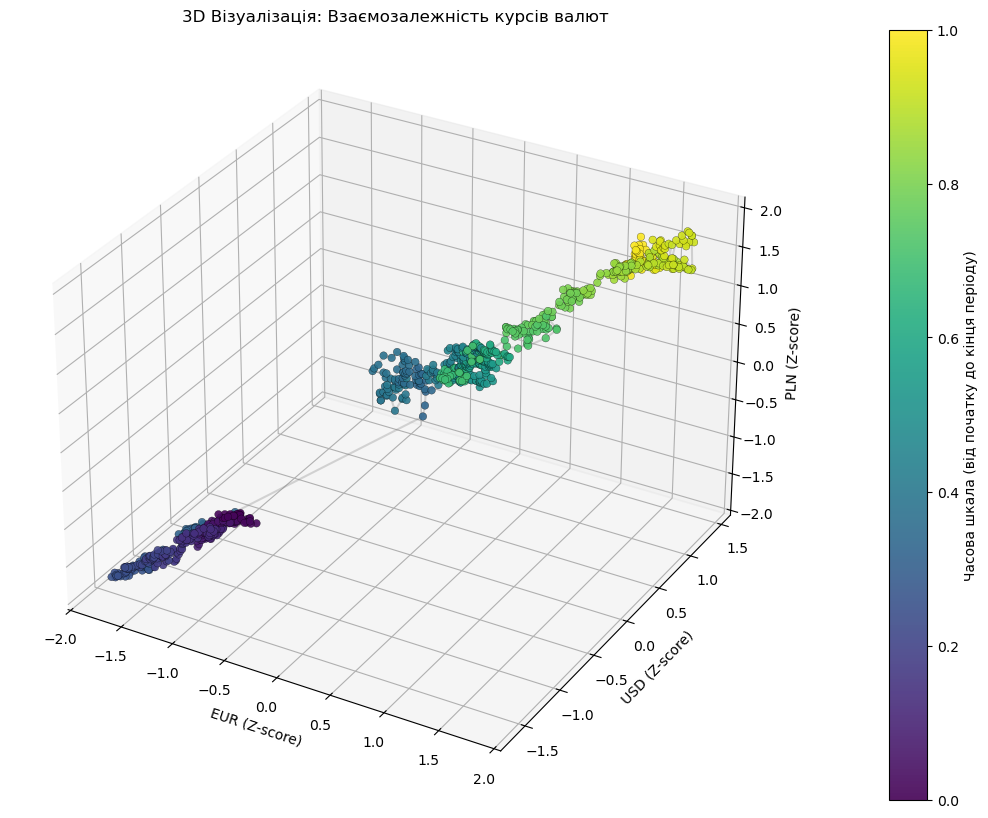


Кореляційна матриця:


,Buy_EUR,Buy_USD,Buy_PLN
Buy_EUR,1.000000,0.957448,0.991446
Buy_USD,0.957448,1.000000,0.966570
Buy_PLN,0.991446,0.966570,1.000000


In [39]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

xs = df_std['Buy_EUR']
ys = df_std['Buy_USD']
zs = df_std['Buy_PLN']

time_colors = np.linspace(0, 1, len(xs))

sc = ax.scatter(xs, ys, zs, c=time_colors, cmap='viridis', s=30, alpha=0.9, edgecolors='k', linewidth=0.2)
ax.plot(xs, ys, zs, color='gray', alpha=0.3)

ax.set_xlabel('EUR (Z-score)')
ax.set_ylabel('USD (Z-score)')
ax.set_zlabel('PLN (Z-score)')
ax.set_title('3D Візуалізація: Взаємозалежність курсів валют')
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('Часова шкала (від початку до кінця періоду)')
plt.show()

print("\nКореляційна матриця:")
df_to_analyse.corr()